In [32]:
import pandas as pd

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_consumption = pd.read_csv(consumption_path)

In [33]:
# Identify feeder columns (assuming time columns are first, feeders are the rest)
time_cols = [col for col in df_consumption.columns if 'time' in col.lower() or 'date' in col.lower()]
feeder_cols = [col for col in df_consumption.columns if col not in time_cols]

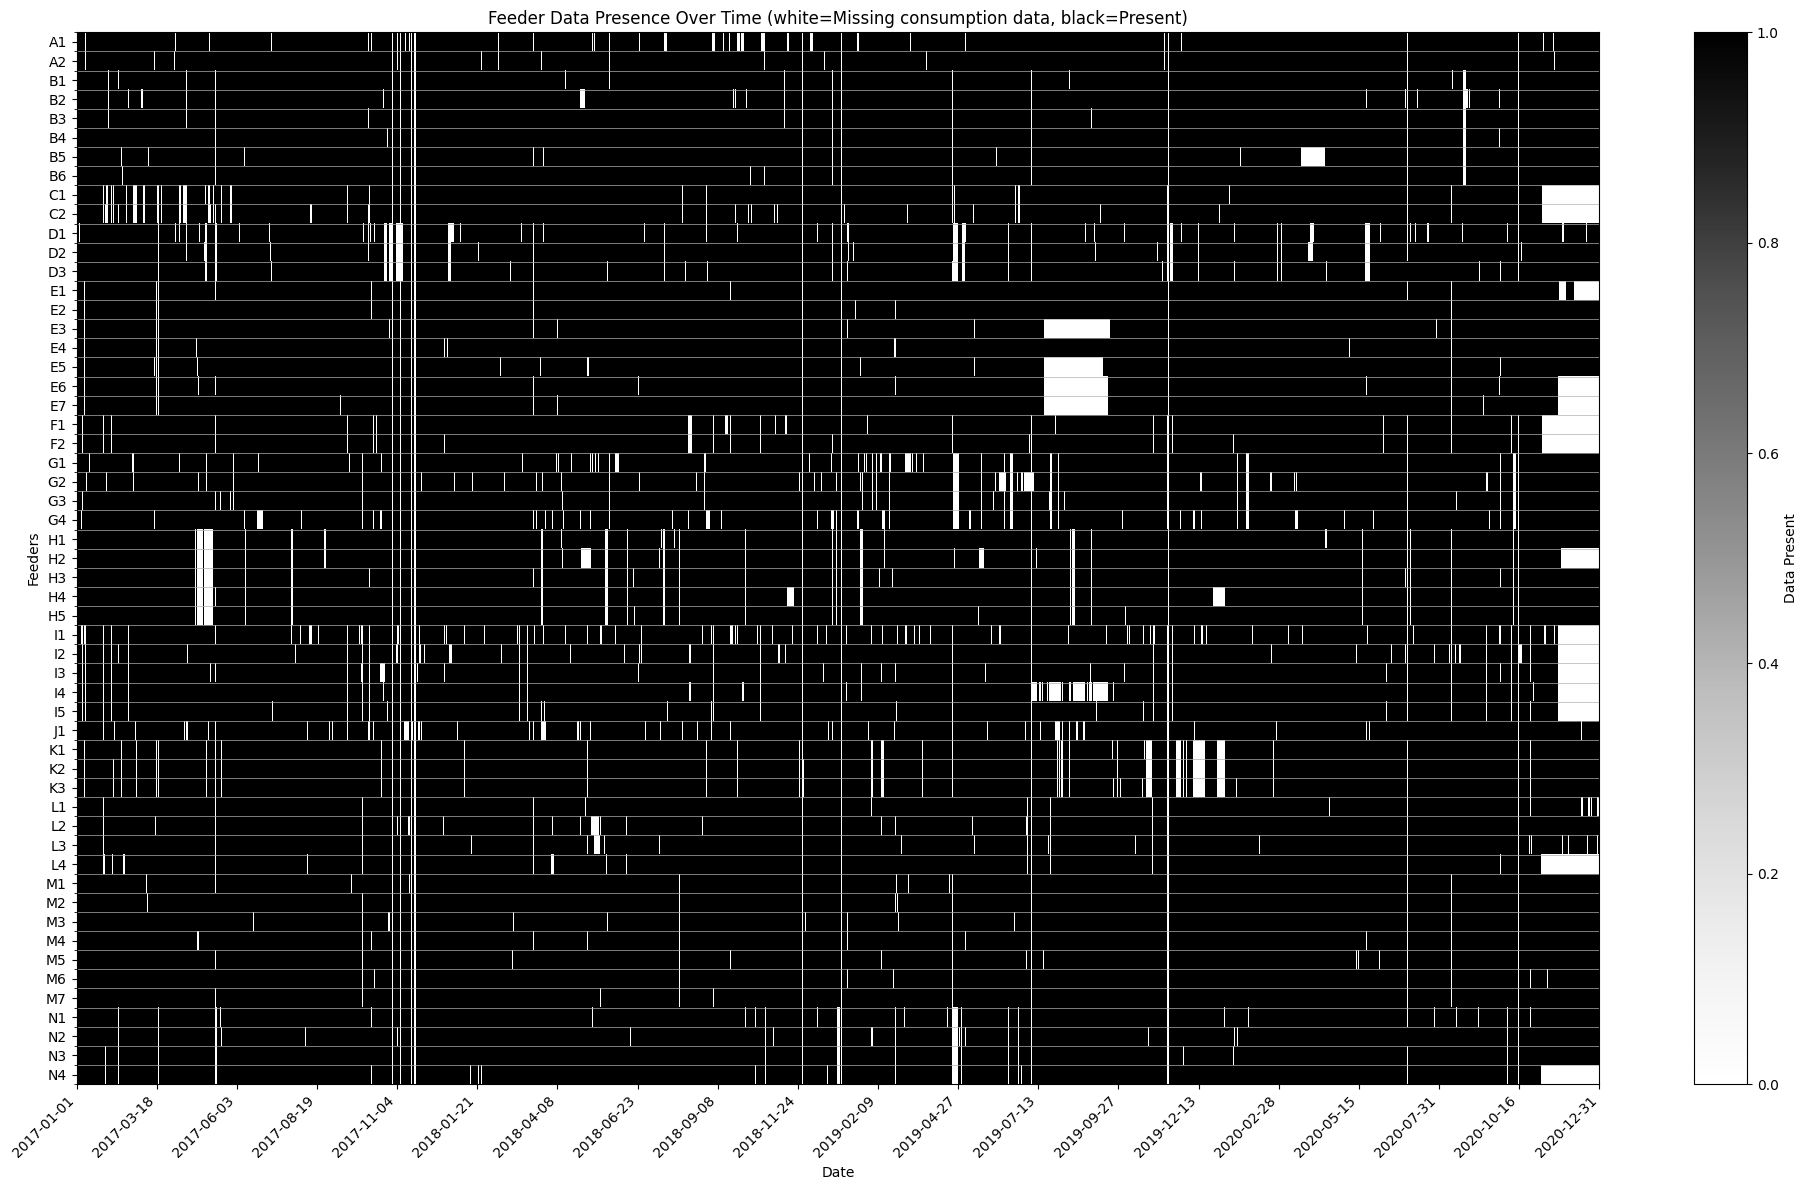

\nFeeder data availability (percentage of time periods with data):
I1: 91.0% available
I4: 91.6% available
E7: 91.8% available
E6: 91.9% available
C2: 92.0% available
H2: 92.5% available
C1: 93.0% available
N4: 93.5% available
I2: 93.7% available
D1: 93.8% available


In [ ]:
# CORRECTED: Visualize missing consumption data over time
import matplotlib.pyplot as plt
import numpy as np

def visualize_missing_data(df_consumption):

    if time_cols and 'feeder' in df_consumption.columns and 'consumption' in df_consumption.columns:
        time_col = time_cols[0]
        
        # Convert time column to datetime if not already
        df_consumption[time_col] = pd.to_datetime(df_consumption[time_col], errors='coerce')
        
        # Create pivot table with consumption values (not feeder names)
        presence = df_consumption.pivot(index=time_col, columns='feeder', values='consumption').notna()
        
        plt.figure(figsize=(20, 12))
        # Note: In this visualization, black = data present, white = data missing
        plt.imshow(presence.T, aspect='auto', interpolation='none', cmap='Greys')
        plt.xlabel('Date')
        plt.ylabel('Feeders')
        plt.title('Feeder Data Presence Over Time (white=Missing consumption data, black=Present)')
        
        # Set x-ticks to show dates
        xticks = np.linspace(0, len(presence.index) - 1, min(20, len(presence.index))).astype(int)
        plt.xticks(xticks, [presence.index[i].strftime('%Y-%m-%d') if not pd.isnull(presence.index[i]) else '' for i in xticks], rotation=45, ha='right', fontsize=10)
        plt.yticks(np.arange(len(presence.columns)), presence.columns, fontsize=10)
        plt.gca().set_yticks(np.arange(-0.5, len(presence.columns), 1), minor=True)
        plt.gca().yaxis.grid(True, which='minor', linestyle='-', linewidth=0.5)
        plt.colorbar(label='Data Present')
        plt.tight_layout()
        plt.show()
        
        # Print some statistics about missing data
        missing_stats = presence.mean().sort_values()
        print("\\nFeeder data availability (percentage of time periods with data):")
        for feeder in missing_stats.index[:10]:  # Show 10 worst feeders
            print(f"{feeder}: {missing_stats[feeder]*100:.1f}% available")
        
    else:
        print("Required columns not found for this plot.")

# Visualize missing data made reusable
visualize_missing_data(df_consumption)


# Comprehensive Missing Data Summary

This section provides a complete analysis of missing consumption data across all feeders.

In [35]:
# Comprehensive Missing Data Analysis
import pandas as pd
import numpy as np
from datetime import timedelta

print("="*80)
print("COMPREHENSIVE MISSING DATA SUMMARY")
print("="*80)

# Define the expected time range (2017-2020, hourly data)
start_date = pd.Timestamp('2017-01-01 00:00:00')
end_date = pd.Timestamp('2020-12-31 23:00:00')
expected_datetime_range = pd.date_range(start=start_date, end=end_date, freq='H')
expected_total_records = len(expected_datetime_range)

print(f"\n📅 EXPECTED DATA PERIOD:")
print(f"   Start: {start_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   End: {end_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Expected records per feeder: {expected_total_records:,} (hourly data)")

# Convert datetime column
df_consumption['datetime'] = pd.to_datetime(df_consumption['datetime'])

# Get all unique feeders
all_feeders = df_consumption['feeder'].unique()
total_feeders = len(all_feeders)

# 1. OVERALL STATISTICS
total_expected_records = expected_total_records * total_feeders
total_actual_records = len(df_consumption)
total_missing_records = total_expected_records - total_actual_records
missing_percentage = (total_missing_records / total_expected_records) * 100

print(f"\n📊 OVERALL STATISTICS:")
print(f"   Total feeders: {total_feeders}")
print(f"   Expected total records: {total_expected_records:,}")
print(f"   Actual records in dataset: {total_actual_records:,}")
print(f"   Missing records: {total_missing_records:,}")
print(f"   Missing percentage: {missing_percentage:.2f}%")
print(f"   Available records: {total_actual_records:,}")

# 2. MISSING DATA BY FEEDER (Top 10 worst)
print(f"\n🔥 TOP 10 FEEDERS WITH MOST MISSING DATA:")
feeder_missing_stats = []

for feeder in all_feeders:
    feeder_data = df_consumption[df_consumption['feeder'] == feeder]
    feeder_actual_records = len(feeder_data)
    feeder_available_records = feeder_data['consumption'].notna().sum()
    feeder_missing_records = expected_total_records - feeder_available_records
    feeder_missing_pct = (feeder_missing_records / expected_total_records) * 100
    
    feeder_missing_stats.append({
        'feeder': feeder,
        'expected_records': expected_total_records,
        'actual_records': feeder_actual_records,
        'available_records': feeder_available_records,
        'missing_records': feeder_missing_records,
        'missing_percentage': feeder_missing_pct
    })

# Sort by missing percentage (descending)
feeder_missing_df = pd.DataFrame(feeder_missing_stats).sort_values('missing_percentage', ascending=False)

print(f"   {'Rank':<4} {'Feeder':<8} {'Missing %':<10} {'Missing/Expected':<17} {'Available':<10}")
print(f"   {'-'*4:<4} {'-'*8:<8} {'-'*10:<10} {'-'*17:<17} {'-'*10:<10}")

for i, row in feeder_missing_df.head(10).iterrows():
    rank = feeder_missing_df.index.get_loc(i) + 1
    print(f"   {rank:<4} {row['feeder']:<8} {row['missing_percentage']:<10.1f} {row['missing_records']:>7,}/{row['expected_records']:<8,} {row['available_records']:>9,}")

# 3. TIME-BASED ANALYSIS
print(f"\n⏰ TIME-BASED MISSING DATA ANALYSIS:")

# Create a complete datetime index for the expected period
complete_datetime_index = expected_datetime_range

# For each year, calculate expected vs actual records
yearly_analysis = []
for year in range(2017, 2021):
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end = pd.Timestamp(f'{year}-12-31 23:59:59')
    
    # Expected records for this year
    year_expected_hours = len(pd.date_range(start=year_start, end=year_end, freq='H'))
    year_expected_total = year_expected_hours * total_feeders
    
    # Actual records for this year
    year_data = df_consumption[
        (df_consumption['datetime'] >= year_start) & 
        (df_consumption['datetime'] <= year_end)
    ]
    year_actual_total = len(year_data)
    year_available_total = year_data['consumption'].notna().sum()
    year_missing_total = year_expected_total - year_available_total
    year_missing_pct = (year_missing_total / year_expected_total) * 100
    
    yearly_analysis.append({
        'year': year,
        'expected_total': year_expected_total,
        'actual_total': year_actual_total,
        'available_total': year_available_total,
        'missing_total': year_missing_total,
        'missing_percentage': year_missing_pct
    })

print(f"   Missing data by year (across all feeders):")
print(f"   {'Year':<6} {'Missing %':<10} {'Missing/Expected':<17} {'Available':<10}")
print(f"   {'-'*6:<6} {'-'*10:<10} {'-'*17:<17} {'-'*10:<10}")
for analysis in yearly_analysis:
    print(f"   {analysis['year']:<6} {analysis['missing_percentage']:<10.1f} {analysis['missing_total']:>7,}/{analysis['expected_total']:<8,} {analysis['available_total']:>9,}")

# 4. BIGGEST TIME GAPS ANALYSIS
print(f"\n🕳️  BIGGEST TIME GAPS (Consecutive missing periods):")

# Find consecutive missing periods for each feeder
def find_missing_gaps(feeder_name, top_n=5):
    feeder_data = df_consumption[df_consumption['feeder'] == feeder_name].copy()
    feeder_data = feeder_data.sort_values('datetime')
    feeder_data['is_missing'] = feeder_data['consumption'].isna()
    
    # Find consecutive missing periods
    feeder_data['gap_group'] = (feeder_data['is_missing'] != feeder_data['is_missing'].shift()).cumsum()
    missing_groups = feeder_data[feeder_data['is_missing']].groupby('gap_group')
    
    gaps = []
    for group_id, group in missing_groups:
        if len(group) > 1:  # Only consider gaps longer than 1 record
            start_time = group['datetime'].min()
            end_time = group['datetime'].max()
            # Calculate actual time difference
            time_diff = end_time - start_time
            duration_hours = time_diff.total_seconds() / 3600
            duration_days = duration_hours / 24
            
            gaps.append({
                'feeder': feeder_name,
                'start': start_time,
                'end': end_time,
                'duration_hours': duration_hours,
                'duration_days': duration_days
            })
    
    return sorted(gaps, key=lambda x: x['duration_hours'], reverse=True)[:top_n]

# Find biggest gaps across all feeders
all_gaps = []
for feeder in feeder_missing_df.head(5)['feeder']:  # Check top 5 feeders with most missing data
    gaps = find_missing_gaps(feeder, top_n=3)
    all_gaps.extend(gaps)

# Sort all gaps by duration
all_gaps = sorted(all_gaps, key=lambda x: x['duration_hours'], reverse=True)[:10]

print(f"   {'Rank':<4} {'Feeder':<8} {'Start Date':<12} {'End Date':<12} {'Duration':<15}")
print(f"   {'-'*4:<4} {'-'*8:<8} {'-'*12:<12} {'-'*12:<12} {'-'*15:<15}")

for i, gap in enumerate(all_gaps, 1):
    start_str = gap['start'].strftime('%Y-%m-%d')
    end_str = gap['end'].strftime('%Y-%m-%d')
    if gap['duration_days'] >= 1:
        duration_str = f"{gap['duration_days']:.1f} days"
    else:
        duration_str = f"{gap['duration_hours']:.0f} hours"
    print(f"   {i:<4} {gap['feeder']:<8} {start_str:<12} {end_str:<12} {duration_str:<15}")

# 5. FEEDER COMPLETENESS SUMMARY
print(f"\n📈 FEEDER DATA COMPLETENESS SUMMARY:")
complete_feeders = feeder_missing_df[feeder_missing_df['missing_percentage'] == 0.0]
mostly_complete = feeder_missing_df[(feeder_missing_df['missing_percentage'] > 0) & (feeder_missing_df['missing_percentage'] <= 10)]
partially_missing = feeder_missing_df[(feeder_missing_df['missing_percentage'] > 10) & (feeder_missing_df['missing_percentage'] <= 50)]
heavily_missing = feeder_missing_df[feeder_missing_df['missing_percentage'] > 50]

print(f"   Complete feeders (0% missing): {len(complete_feeders)} ({len(complete_feeders)/total_feeders*100:.1f}%)")
print(f"   Mostly complete (0-10% missing): {len(mostly_complete)} ({len(mostly_complete)/total_feeders*100:.1f}%)")
print(f"   Partially missing (10-50% missing): {len(partially_missing)} ({len(partially_missing)/total_feeders*100:.1f}%)")
print(f"   Heavily missing (>50% missing): {len(heavily_missing)} ({len(heavily_missing)/total_feeders*100:.1f}%)")

print(f"\n" + "="*80)

COMPREHENSIVE MISSING DATA SUMMARY

📅 EXPECTED DATA PERIOD:
   Start: 2017-01-01 00:00
   End: 2020-12-31 23:00
   Expected records per feeder: 35,064 (hourly data)

📊 OVERALL STATISTICS:
   Total feeders: 55
   Expected total records: 1,928,520
   Actual records in dataset: 1,899,312
   Missing records: 29,208
   Missing percentage: 1.51%
   Available records: 1,899,312

🔥 TOP 10 FEEDERS WITH MOST MISSING DATA:


C:\Users\knuto\AppData\Local\Temp\ipykernel_48104\1646887757.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_datetime_range = pd.date_range(start=start_date, end=end_date, freq='H')


COMPREHENSIVE MISSING DATA SUMMARY

📅 EXPECTED DATA PERIOD:
   Start: 2017-01-01 00:00
   End: 2020-12-31 23:00
   Expected records per feeder: 35,064 (hourly data)

📊 OVERALL STATISTICS:
   Total feeders: 55
   Expected total records: 1,928,520
   Actual records in dataset: 1,899,312
   Missing records: 29,208
   Missing percentage: 1.51%
   Available records: 1,899,312

🔥 TOP 10 FEEDERS WITH MOST MISSING DATA:


C:\Users\knuto\AppData\Local\Temp\ipykernel_48104\1646887757.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_datetime_range = pd.date_range(start=start_date, end=end_date, freq='H')


   Rank Feeder   Missing %  Missing/Expected  Available 
   ---- -------- ---------- ----------------- ----------
   1    I1       9.1          3,194/35,064      31,870
   2    I4       8.5          2,976/35,064      32,088
   3    E7       8.3          2,908/35,064      32,156
   4    E6       8.2          2,861/35,064      32,203
   5    C2       8.1          2,827/35,064      32,237
   6    H2       7.6          2,652/35,064      32,412
   7    C1       7.1          2,481/35,064      32,583
   8    N4       6.5          2,286/35,064      32,778
   9    I2       6.4          2,247/35,064      32,817
   10   D1       6.3          2,202/35,064      32,862

⏰ TIME-BASED MISSING DATA ANALYSIS:
   Missing data by year (across all feeders):
   Year   Missing %  Missing/Expected  Available 
   ------ ---------- ----------------- ----------
   2017   3.8         18,213/481,800    463,587
   2018   2.7         12,879/481,800    468,921
   2019   4.9         23,459/481,800    458,341
   2020  

...

COMPREHENSIVE MISSING DATA SUMMARY

📅 EXPECTED DATA PERIOD:
   Start: 2017-01-01 00:00
   End: 2020-12-31 23:00
   Expected records per feeder: 35,064 (hourly data)

📊 OVERALL STATISTICS:
   Total feeders: 55
   Expected total records: 1,928,520
   Actual records in dataset: 1,899,312
   Missing records: 29,208
   Missing percentage: 1.51%
   Available records: 1,899,312

🔥 TOP 10 FEEDERS WITH MOST MISSING DATA:


C:\Users\knuto\AppData\Local\Temp\ipykernel_48104\1646887757.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_datetime_range = pd.date_range(start=start_date, end=end_date, freq='H')


   Rank Feeder   Missing %  Missing/Expected  Available 
   ---- -------- ---------- ----------------- ----------
   1    I1       9.1          3,194/35,064      31,870
   2    I4       8.5          2,976/35,064      32,088
   3    E7       8.3          2,908/35,064      32,156
   4    E6       8.2          2,861/35,064      32,203
   5    C2       8.1          2,827/35,064      32,237
   6    H2       7.6          2,652/35,064      32,412
   7    C1       7.1          2,481/35,064      32,583
   8    N4       6.5          2,286/35,064      32,778
   9    I2       6.4          2,247/35,064      32,817
   10   D1       6.3          2,202/35,064      32,862

⏰ TIME-BASED MISSING DATA ANALYSIS:
   Missing data by year (across all feeders):
   Year   Missing %  Missing/Expected  Available 
   ------ ---------- ----------------- ----------
   2017   3.8         18,213/481,800    463,587
   2018   2.7         12,879/481,800    468,921
   2019   4.9         23,459/481,800    458,341
   2020  

C:\Users\knuto\AppData\Local\Temp\ipykernel_48104\1646887757.py:85: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_expected_hours = len(pd.date_range(start=year_start, end=year_end, freq='H'))


   Rank Feeder   Start Date   End Date     Duration       
   ---- -------- ------------ ------------ ---------------
   1    E6       2019-07-17   2019-09-17   61.9 days      
   2    E7       2019-08-16   2019-09-17   31.8 days      
   3    E7       2019-07-17   2019-08-16   30.0 days      
   4    I4       2019-07-12   2019-07-15   2.5 days       
   5    I1       2017-11-06   2017-11-08   2.4 days       
   6    I4       2017-11-06   2017-11-08   2.4 days       
   7    E7       2017-11-06   2017-11-08   2.4 days       
   8    E6       2017-11-06   2017-11-08   2.4 days       
   9    C2       2017-11-06   2017-11-08   2.4 days       
   10   I4       2018-08-11   2018-08-13   1.9 days       

📈 FEEDER DATA COMPLETENESS SUMMARY:
   Complete feeders (0% missing): 0 (0.0%)
   Mostly complete (0-10% missing): 55 (100.0%)
   Partially missing (10-50% missing): 0 (0.0%)
   Heavily missing (>50% missing): 0 (0.0%)

